In [108]:
import sys
from pathlib import Path


BASE_DIR = Path.cwd()

# go UP until we find 'src'
while BASE_DIR != BASE_DIR.parent:
    if (BASE_DIR / "src").exists():
        break
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR / "src"))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from models.isolation_forest import IsolationForest
from models.dbscan import DBSCAN
from datetime import date,datetime
from dateutil.relativedelta import relativedelta


import warnings

warnings.filterwarnings("ignore")

## Input Parameters

In [109]:
data_type = "intraday"
timeframe = "5min"

data_type = "interday"
timeframe = "5D"

stock_name = "CHCL"
features = ["close", "volume", "returns", "volatility"]



z_score_threshold = 3

n_estimators = 200
contamination = 0.01

epsilon = 0.5
min_samples = 5




## Loader

In [110]:
# Data type
if data_type == "intraday":

    all_days = []
    start_date = datetime.strptime("2026-04-09","%Y-%m-%d")
    end_date = datetime.strptime("2026-04-30","%Y-%m-%d")

    for date_folder in sorted(Path("./../../data/intraday").iterdir()):
        if not date_folder.is_dir():
            continue

        date = datetime.strptime(date_folder.name, "%Y-%m-%d")
        if start_date <= date <= end_date:
            file_path = date_folder / f"{stock_name}.csv"

            if file_path.exists():
                df = pd.read_csv(file_path)
                df["transaction_time"] = pd.to_datetime(df["transaction_time"])
                df = df.set_index("transaction_time")
                df = df.sort_index()

                all_days.append(df)

    if not all_days:
        # if no data found returns an empty dataframe
        df = pd.DataFrame()
    else:
        # returns a concatenated dataframe and ignore the index of the dataframe and generate a brand new set of indices
        df = pd.concat(all_days).sort_index()
        df = df.reset_index();
    


  


else:

    start_date = date.today() - relativedelta(years=3)
    end_date = date.today()

    print(start_date)
    print(end_date)

    data_source = stock_name + ".csv"

    df = pd.read_csv(f"{BASE_DIR}/data/interday/{data_source}")


df.head()



2023-05-04
2026-05-04


,transaction_time,open,high,low,close,volume,amount
0,2006-06-13,800.0,281.0,276.0,281.0,260950.0,0.0
1,2006-06-14,281.0,336.0,295.0,336.0,99810.0,0.0
2,2006-06-15,336.0,352.0,352.0,352.0,1540.0,0.0
3,2006-06-18,352.0,369.0,369.0,369.0,300.0,0.0
4,2006-06-20,369.0,387.0,387.0,387.0,3640.0,0.0


In [111]:
from plotly.graph_objs import volume

df["Date"] = pd.to_datetime(df["transaction_time"])
df = df.set_index("Date")
df = df.sort_index();

if data_type=='interday':
    df = df.resample(timeframe).agg(
        open = ("open","first"),
        high = ("high","max"),
        low = ("low","min"),
        close = ("close","last"),
        volume = ("volume","sum"),
    )
elif data_type=='intraday':
    df = df.resample(timeframe).agg(
        open = ("price","first"),
        high = ("price","max"),
        low = ("price","min"),
        close = ("price","last"),
        volume = ("volume","sum")
    )




## Data preprocessing

In [112]:
# Data preprocessing
# print(df.columns)

df = df.loc[start_date:end_date].copy()

# drop unnecessary columns
df = df.drop(columns=["transaction_time"],errors="ignore")


# Filter dataframe
df = df.drop_duplicates()

# Compute returns
df["returns"] = df["close"].pct_change()
df["close"] = df["close"].replace(0, np.nan)
df["volatility"] = df["returns"].rolling(window=20).std()


print(df[["close", "volume", "returns", "volatility"]].isna().sum())

df.head()

close          1
volume         0
returns        1
volatility    20
dtype: int64


,open,high,low,close,volume,returns,volatility
Date,,,,,,,
2023-05-05,460.1,468.9,457.0,464.0,28131.0,NaN,NaN
2023-05-10,464.0,477.5,460.0,464.0,27722.0,0.000000,NaN
2023-05-15,463.0,470.1,454.6,468.9,47562.0,0.010560,NaN
2023-05-20,473.0,485.0,462.0,475.5,99013.0,0.014075,NaN
2023-05-25,482.0,510.0,482.0,504.0,167293.0,0.059937,NaN


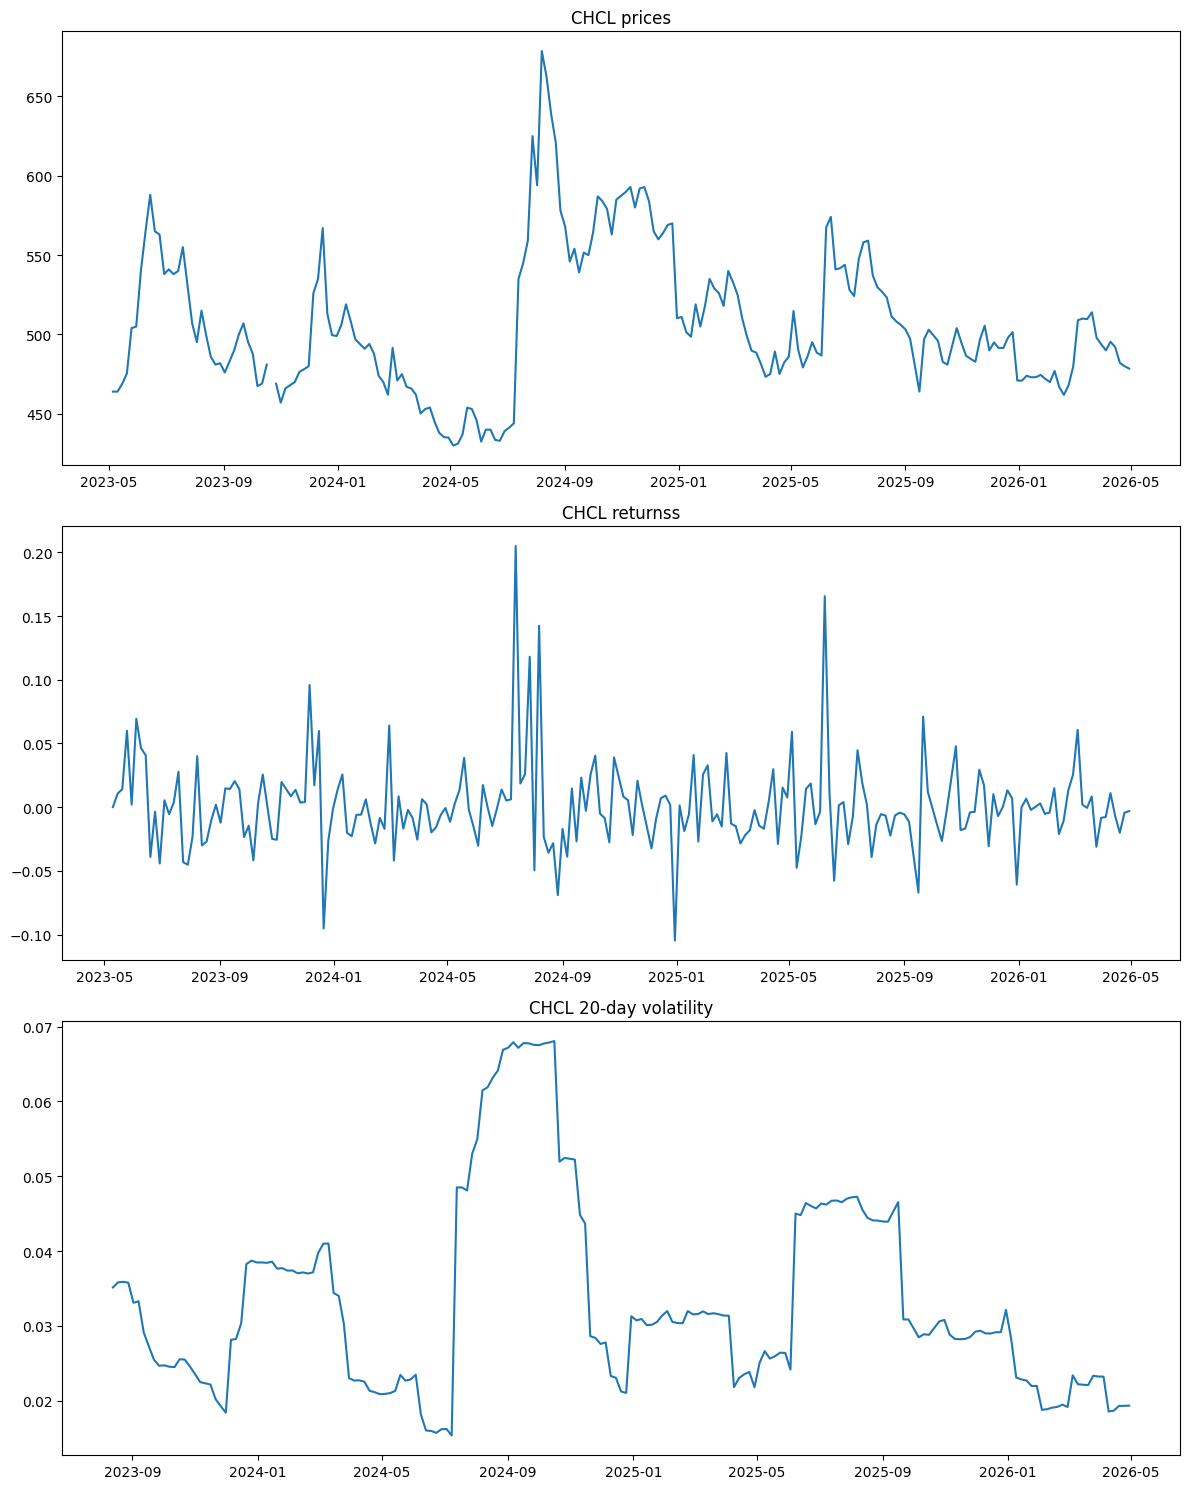

In [113]:
# Plot volatitlity and percent change

fig, axes = plt.subplots(3, 1, figsize=(12, 15))
axes[0].plot(df.index, df["close"])
axes[0].set_title(f"{stock_name} prices")
axes[1].plot(df.index, df["returns"])
axes[1].set_title(f"{stock_name} returnss")
axes[2].plot(df.index, df["volatility"])
axes[2].set_title(f"{stock_name} 20-day volatility")
plt.tight_layout()

plt.show()

In [114]:
# Feature Selection

df[features] = df[features].apply(
    pd.to_numeric, errors="coerce"
)  # converts every value in features columns to numeric value
df.replace(
    [np.inf, -np.inf], np.nan, inplace=True
)  # replace inf and -inf with NaN inplace means in the original dataframe
df = df.dropna(subset=features)  # drops rows where any of the features are NaN

In [115]:
# Feature Enginneering


# 1. Calculate Simple moving averages of last N days

df["SMA_10"] = df["close"].rolling(window=10).mean()
df["SMA_20"] = df["close"].rolling(window=20).mean()
df["SMA_50"] = df["close"].rolling(window=50).mean()


# 2. Calculate Relative Strength Index
def calculate_rsi(data, periods=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=periods).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=periods).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))


df["RSI"] = calculate_rsi(df["close"])


# Above 70 → asset may be overbought (close went up too fast, may pull back)
# Below 30 → asset may be oversold (close dropped too fast, may bounce back)
# Around 50 → neutral momentum


# 3. Calculate Boilinger bands
df["Upper_BB"] = df["SMA_20"] + (df["close"].rolling(window=20).std() * 2)
df["Lower_BB"] = df["SMA_20"] - (df["close"].rolling(window=20).std() * 2)

df.tail()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB
Date,,,,,,,,,,,,,
2026-04-09,490.0,503.0,485.0,495.4,117221.0,0.011020,0.018548,496.78,484.055,494.0262,61.016949,517.658664,450.451336
2026-04-14,495.1,502.9,488.1,492.0,84915.0,-0.006863,0.018662,499.18,485.110,492.6840,60.223048,518.296992,451.923008
2026-04-19,497.1,497.1,476.0,482.1,81860.0,-0.020122,0.019289,499.40,485.515,491.5820,52.307692,518.326697,452.703303
2026-04-24,486.9,486.9,475.0,480.0,75121.0,-0.004356,0.019314,496.50,485.865,490.5870,56.390244,518.261314,453.468686
2026-04-29,480.0,484.9,473.0,478.5,59588.0,-0.003125,0.019335,493.35,486.135,489.6200,58.383838,518.171379,454.098621


In [116]:
# Plot technical analysis
import plotly.graph_objects as go


# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close",
        line=dict(color="blue", width=2),
    )
)

# Add 'SMA 10' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_10"],
        mode="lines",
        name="SMA 10",
        line=dict(color="green", width=2, dash="dot"),
    )
)

# Add 'SMA 50' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["SMA_50"],
        mode="lines",
        name="SMA 50",
        line=dict(color="orange", width=2, dash="dash"),
    )
)

# Add 'Upper BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Upper_BB"],
        mode="lines",
        name="Upper BB",
        line=dict(color="red", width=1, dash="dot"),
    )
)

# Add 'Lower BB' line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Lower_BB"],
        mode="lines",
        name="Lower BB",
        line=dict(color="purple", width=1, dash="dot"),
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock close with Technical Indicators",
    xaxis_title="Date",
    yaxis_title="Stock close",
    legend=dict(
        x=0, y=1, bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)"
    ),
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

# Anomaly Detection Techniques

## Z Score Model


In [ ]:
from scipy.stats import zscore
import plotly.graph_objects as go


# Calculate Z Score for close prices
df["Anomaly_Z_Score"] = zscore(df["close"])

# Identify anomalies where Z-Score >3 or < -3
anomalies_zscore = df[abs(df["Anomaly_Z_Score"]) > z_score_threshold]

# Create the figure
fig = go.Figure()

# Add 'Close' close line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Z-score > 3 or < -3) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"],
        mode="markers",
        name="Anomalies (Z-Score)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock prices with Anomalies Detected Using Z-Score",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()
# df.sort_values(by="Anomaly_Z_Score",ascending=False).head()
anomalies_zscore.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score
Date,,,,,,,,,,,,,,
2024-08-07,582.2,697.0,582.2,678.6,1415901.0,0.142424,0.061478,529.38,484.545,483.536,84.654350,636.809776,332.280224,3.792652
2024-08-12,678.6,690.0,654.1,662.7,1289396.0,-0.023431,0.061899,552.35,496.180,486.270,84.053254,665.502646,326.857354,3.444617


## Standardization 

To standardize means to convert the data to have a mean of 0 and a standard deviation of 1 such that the data is normalized and the model can learn better
this is important because the model is sensitive to the scale of the data as returns maybe in the range of -0.2 to 0.2 but the other features are in the range of 1000 to 1000000 like quantity

In [ ]:
# Only take the selected features
X = df[features]

scaler = StandardScaler()
X = scaler.fit_transform(X)

## Isolation Forest Approach

Anomalies are easier to isolate than normal points and
because anomalies are rare and far from the cluster, a random split can isolate them quickly.
Normal points are surrounded by many neighbors, so they require more splits

It takes 3 parameters:

**1. n_estimators:** 200 means 200 independent trees are built and then sees how quickly a given point gets isolated across these trees.  
**2. contamination:** 0.01 assumes that 1% of the data is anomalous  
**3. max_depth:** cap a trees height  
**4. random_state:** for reproducibility purposes as without it every run gives slightly different anomalies

Random seed → geneprice random splits  
 ↓  
Build 200 isolation trees  
 ↓  
Compute anomaly scores  
 ↓  
Use contamination (1%) to label anomalies

isolation forest converts the average path length to scores  
short path → high anomaly score  
long path → low anomaly score

max-depth = ceil(log2(max_samples))  
len(X) is how many training rows you have.  
np.log2(n) is “how many times can you halve n before you get down to ~1” — a standard rough size for depth in random/binary tree pictures.  
np.ceil(...) rounds up so you always get an integer depth.  
int(...) makes it a plain Python int for your IsolationForest.

if training data becomes huge we instead find depth by choosing a max-sample size to randomly select samples to cap a tree's height


In [119]:
# We can also train the model and fit it in test data, But for simplicity purposes we will fit the model on the entire dataset.

# split_idx = int(len(df) * 0.8) #splits the dataframe into 80% train and 20% test
# df_train = df.iloc[:split_idx].copy() #creates a copy of the train dataframe from the first 80% of the dataframe
# df_test = df.iloc[split_idx:].copy() #creates a copy of the test dataframe from the last 20% of the dataframe


model_if = IsolationForest(
    n_trees=n_estimators, contamination=contamination, random_state=42
)

df["Anomaly_Isolation_Forest"] = model_if.fit_predict(X)

anomalies_if = df[df["Anomaly_Isolation_Forest"] == -1]


anomalies_if.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest
Date,,,,,,,,,,,,,,,
2024-08-07,582.2,697.0,582.2,678.60,1415901.0,0.142424,0.061478,529.380,484.5450,483.5360,84.654350,636.809776,332.280224,3.792652,-1
2025-06-08,496.5,589.0,487.0,567.37,2945630.0,0.165581,0.045009,497.668,494.1535,528.9814,69.669766,537.680165,450.626835,1.357938,-1


In [ ]:
fig = go.Figure()

# Add Close prices line
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue", width=2),
    )
)

# Add anomalies (Isolation Forest) as red markers
fig.add_trace(
    go.Scatter(
        x=anomalies_if.index,
        y=anomalies_if["close"],
        mode="markers",
        name="Anomalies (Isolation Forest)",
        marker=dict(color="red", size=8, symbol="circle"),
        showlegend=True,
    )
)

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock prices with Anomalies Detected Using Isolation Forest",
    xaxis_title="Date",
    yaxis_title="Stock close",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

## DBSCAN

DBSCAN finds anomalies by clustering the data points into density based clusters. It has 2 parameters

**eps:** It is the radius of the neighborhood around a data point, i.e the max-distance between two samples for them to be considered neighbors  
**min_pts:** The minimum number of data points required within the eps radius to form a dense region.


In [121]:
dbscan = DBSCAN(eps=epsilon, min_pts=min_samples)
df["Anomaly_DBSCAN"] = dbscan.fit_predict(X)

anomalies_dbscan = df.copy()
anomalies_dbscan["Color"] = anomalies_dbscan["Anomaly_DBSCAN"].apply(
    lambda x: "red" if x == -1 else "blue"
)
anomalies_dbscan.head()

,open,high,low,close,volume,returns,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest,Anomaly_DBSCAN,Color
Date,,,,,,,,,,,,,,,,,
2023-08-13,515.0,523.8,491.1,499.5,182462.0,-0.030097,0.035129,NaN,NaN,NaN,NaN,NaN,NaN,-0.127670,1,1,blue
2023-08-18,500.0,500.0,477.1,486.0,87707.0,-0.027027,0.035816,NaN,NaN,NaN,NaN,NaN,NaN,-0.423171,1,1,blue
2023-08-23,483.2,504.0,480.2,481.0,60909.0,-0.010288,0.035885,NaN,NaN,NaN,NaN,NaN,NaN,-0.532616,1,1,blue
2023-08-28,481.0,486.0,477.1,481.9,35533.0,0.001871,0.035770,NaN,NaN,NaN,NaN,NaN,NaN,-0.512916,1,1,blue
2023-09-02,476.1,487.0,470.0,476.0,41784.0,-0.012243,0.033080,NaN,NaN,NaN,NaN,NaN,NaN,-0.642061,1,1,blue


In [122]:
import plotly.express as px

fig = px.scatter(
    anomalies_dbscan,
    x="close",
    y="volume",
    color="Color",
    title=f"DBSCAN Clustering Results on {stock_name} Data",
    labels={"Color": "Cluster"},
    hover_data=["returns", "volatility"],  # Add more data to hover
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title="Close prices",
    yaxis_title="volume",
    legend_title="Cluster",
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()

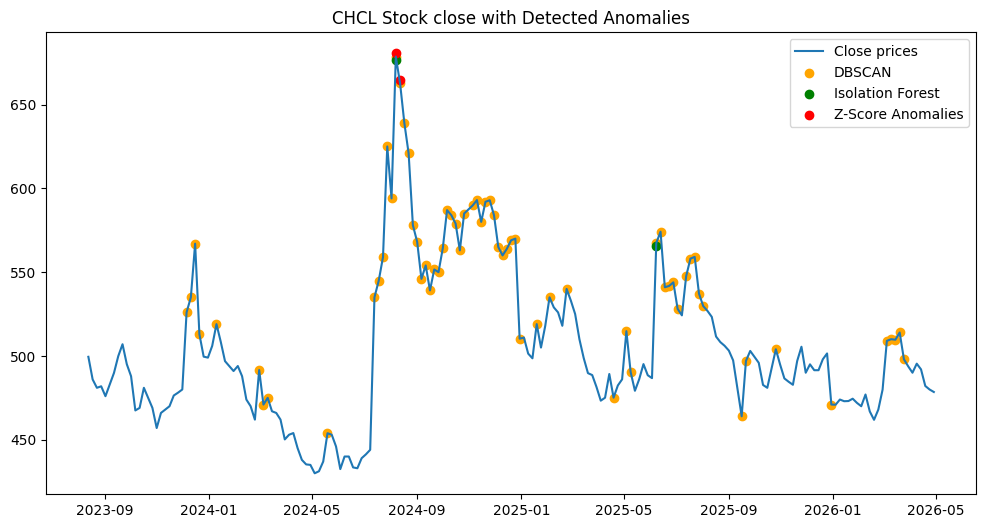

In [123]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["close"], label="Close prices")


plt.scatter(
    df[df["Anomaly_DBSCAN"] == -1].index,
    df[df["Anomaly_DBSCAN"] == -1]["close"],
    color="orange",
    label="DBSCAN",
)

plt.scatter(
    df[df["Anomaly_Isolation_Forest"] == -1].index,
    df[df["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
    color="green",
    label="Isolation Forest",
)

plt.scatter(
    anomalies_zscore.index,
    anomalies_zscore["close"] + 2,
    color="red",
    label="Z-Score Anomalies",
)

plt.title(f"{stock_name} Stock close with Detected Anomalies")
plt.legend()
plt.show()

In [124]:
import plotly.graph_objects as go


fig = go.Figure()

# Add the line for the closing close
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["close"],
        mode="lines",
        name="Close prices",
        line=dict(color="blue"),
    )
)


# Add the scatter plot for Isolation Forest anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1].index,
        y=anomalies_if[anomalies_if["Anomaly_Isolation_Forest"] == -1]["close"] - 2,
        mode="markers",
        name="Isolation Forest Anomalies",
        marker=dict(color="green", size=10),
    )
)

# Add the scatter plot for DBSCAN anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1].index,
        y=anomalies_dbscan[anomalies_dbscan["Anomaly_DBSCAN"] == -1]["close"],
        mode="markers",
        name="DBSCAN Anomalies",
        marker=dict(color="orange", size=10),
    )
)

# Add the scatter plot for Z-Score anomalies
fig.add_trace(
    go.Scatter(
        x=anomalies_zscore.index,
        y=anomalies_zscore["close"] + 2,
        mode="markers",
        name="Z-Score Anomalies",
        marker=dict(color="red", size=10),
    )
)


# Update layout
fig.update_layout(
    title=f"{stock_name} Stock close with Detected Anomalies",
    xaxis_title="Date",
    yaxis_title="Close prices",
    legend_title="Legend",
    width=1200,
    height=600,
)

# Show the plot
fig.show()

In [125]:
print("Number of Z-Score Anomalies:", len(anomalies_zscore))
print("Number of Isolation Forest Anomalies:", len(anomalies_if['Anomaly_Isolation_Forest'] == -1))
print("Number of DBSCAN Anomalies:", sum(anomalies_dbscan["Anomaly_DBSCAN"] == -1))

Number of Z-Score Anomalies: 2
Number of Isolation Forest Anomalies: 2
Number of DBSCAN Anomalies: 69


3

Confusion Matrix for Z_Score:
[[190   0]
 [  1   2]]


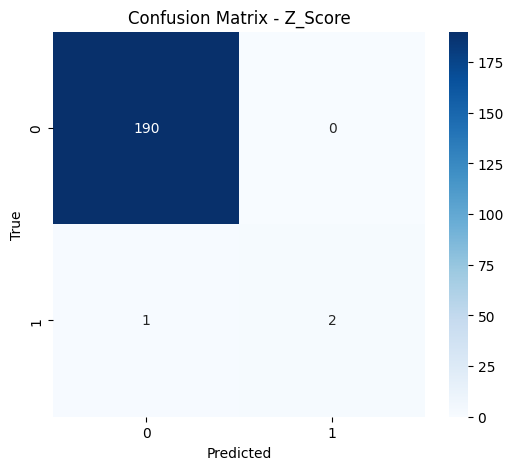


Confusion Matrix for Isolation_Forest:
[[190   0]
 [  1   2]]


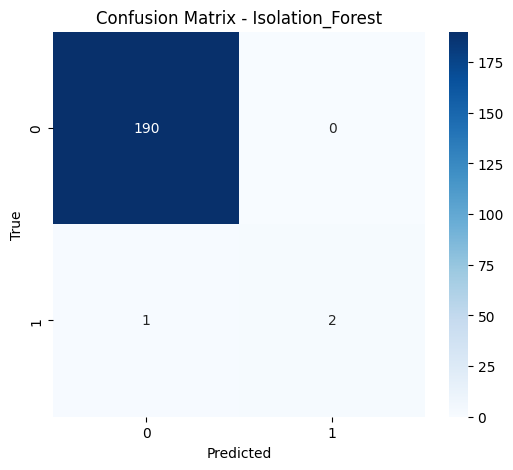


Confusion Matrix for DBSCAN:
[[124  66]
 [  0   3]]


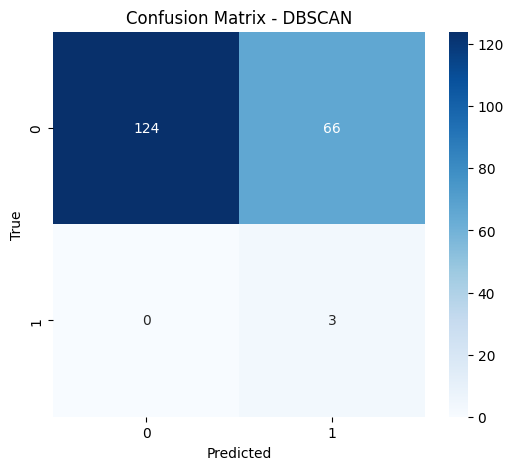


Comparison of all methods:
             Method  Precision    Recall  F1-Score
0           Z_Score   1.000000  0.666667  0.800000
1  Isolation_Forest   1.000000  0.666667  0.800000
2            DBSCAN   0.043478  1.000000  0.083333


In [126]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# df["True_Anomaly"] = df["close"].pct_change().abs() > 0.05
df["True_Anomaly"] = (
    (abs(df["Anomaly_Z_Score"]) > z_score_threshold).astype(int) +
    (df["Anomaly_Isolation_Forest"] == -1).astype(int) +
    (df["Anomaly_DBSCAN"] == -1).astype(int)
) >= 2

print(len(df[df["True_Anomaly"]]))


methods = ["Z_Score", "Isolation_Forest", "DBSCAN"]
results = []

for method in methods:
    if method == "Z_Score":
        predictions = (abs(df["Anomaly_Z_Score"]) > z_score_threshold).astype(int)
    elif method == "Isolation_Forest":
        predictions = (df["Anomaly_Isolation_Forest"] == -1).astype(int)
    elif method == "DBSCAN":
        predictions = (df["Anomaly_DBSCAN"] == -1).astype(int)

    precision = precision_score(df["True_Anomaly"], predictions)
    recall = recall_score(df["True_Anomaly"], predictions)
    f1 = f1_score(df["True_Anomaly"], predictions)

    cm = confusion_matrix(df["True_Anomaly"], predictions)

    print(f"\nConfusion Matrix for {method}:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {method}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

    results.append(
        {"Method": method, "Precision": precision, "Recall": recall, "F1-Score": f1}
    )

results_df = pd.DataFrame(results)
print("\nComparison of all methods:")
print(results_df)